# Phase I

## prompt count, total prompt length, avg prompt lenght

In [ ]:
import pandas as pd 
from pathlib import Path


def find_data_dir(start_path=None):
    """
    Find the project's Data/data folder by searching the current
    directory and its parent directories.
    """
    start_path = Path(start_path or Path.cwd()).resolve()

    for directory in [start_path, *start_path.parents]:
        for folder_name in ("Data", "data"):
            candidate = directory / folder_name

            if candidate.is_dir():
                return candidate

    raise FileNotFoundError(
        f"Could not find a 'Data' or 'data' directory from: {start_path}"
    )


DATA_DIR = find_data_dir()

path = DATA_DIR / "prompt_data" / "Phase1_prompt_type.csv"
summary_path = DATA_DIR / "prompt_data" / "Phase1_prompt_summary.csv"

if not path.is_file():
    raise FileNotFoundError(
        f"Prompt type file not found: {path}"
    )

print(f"Data directory: {DATA_DIR}")
print(f"Using prompt type file: {path}")

df = pd.read_csv(path)
print(f"Dataframe loaded from {path}. Shape: {df.shape}")
# count words per prompt
df["prompt_len"] = (
    df["prompt_text"]
    .fillna("")
    .str.split()
    .str.len()
)

# aggregate by id
df_summary = (
    df.groupby("id")
    .agg(
        total_prompt_count=("prompt_id", "count"),
        total_prompt_len=("prompt_len", "sum"),
        average_prompt_len=("prompt_len", "mean"),
    )
    .reset_index()
)
# df_summary.to_csv("Phase1_prompt_summary.csv", index=False)
df_summary = pd.read_csv(summary_path)
print(df_summary.head())
df_summary.describe()

      id  total_prompt_count  total_prompt_len  average_prompt_len  \
0  S0001                   6               919          153.166667   
1  S0002                   7               229           32.714286   
2  S0003                   9               867           96.333333   
3  S0005                   6               567           94.500000   
4  S0006                   3                28            9.333333   

   clarification_count  debugging_count  code_generation_count  \
0                    4                1                      0   
1                    3                2                      0   
2                    4                0                      2   
3                    3                0                      1   
4                    2                0                      0   

   test_generation_count  
0                      1  
1                      2  
2                      3  
3                      2  
4                      1  


,total_prompt_count,total_prompt_len,average_prompt_len,clarification_count,debugging_count,code_generation_count,test_generation_count
count,70.000000,70.00000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,4.871429,598.60000,136.688980,1.500000,0.942857,1.514286,0.914286
std,2.982662,523.75828,107.386014,2.151845,1.178131,1.151469,0.974201
min,1.000000,4.00000,4.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,236.50000,60.223214,0.000000,0.000000,1.000000,0.000000
50%,4.000000,473.50000,113.500000,1.000000,1.000000,2.000000,1.000000
75%,6.000000,828.25000,187.000000,2.000000,1.000000,2.000000,2.000000
max,17.000000,2796.00000,476.666667,12.000000,6.000000,6.000000,4.000000


## Labelling Prompt types

In [ ]:
import pandas as pd 
path ="Phase1_prompt_type.csv"
df = pd.read_csv(path)
print(f"Dataframe loaded from {path}. Shape: {df.shape}")
df["prompt_category"] = ""
df.head()

In [ ]:
def get_G2_spec(row):
    acceptance_criteria = row["before_g2_ac"],
    constraints=row["before_g2_constraints"],
    return f"acceptance criteria: {acceptance_criteria}, constraints: {constraints}"

def get_G3_spec(row):
    constraints=row["before_g3_constraints"]
    frs = row["before_g3_frs"]
    invariants = row["before_g3_invariants"]
    tiebreaking = row["before_g3_tie_breaking"]
    exception = row["before_g3_exception"]
    neg_req = row["before_g3_neg_req"]
    return f" constraints: {constraints}, functional requirements: {frs}, invariants: {invariants}, tiebreaking: {tiebreaking}, exception: {exception}, negative requirements: {neg_req}"

def get_prompt(row):
        prompt = f"""
        You are an expert requirement engineering. You are given an interaction log of a developer interacting with an LLM. 
        Your task is:
        1. Determine the goal of the developer in the interactions. 
        2. label the interaction as one of: (i) clarification, (ii) debugging, (iii) code generation only, (iv) test-generation.
        3. Provide a short justification.
        4. Use this template for output and do not use anything else:
        {{"category": "<clarification / debugging / code generation only / test-generation>", "Reason": "<brief explanation>"}}
        5. Only output the JSON without any additional text.
 
        Developer interaction:
        {row["prompt_text"]}
        """
    
        return prompt

In [ ]:
from pathlib import Path
import time
import pandas as pd
from tqdm import tqdm
from groq import Groq

api_keys = [
    # Add your API keys here
]

models = [
    # Add your model names here we used openai/gpt-oss-120b 
]


participant_list = sorted(df["id"].dropna().unique())

for idx, row in df.iterrows():
        print(f"\nWorking on {row['id']}: {idx} / {len(df)}")
        if not (pd.isna(row["prompt_category"]) or row["prompt_category"] == ""):
                continue
    
        prompt = get_prompt(row)
        success = False

        for model in models:
            print(f"\nTrying model: {model}")
            for api_key_idx, api_key in enumerate(api_keys, start=1):
                try:
                    client = Groq(api_key=api_key)
                    response = client.chat.completions.create(
                        messages=[{"role": "user", "content": prompt}],
                        model=model,
                        temperature=0
                    )
                    result = response.choices[0].message.content
                    print(result)
                    df.loc[idx, "prompt_category"] = result
                    success = True
                    time.sleep(2)
                    break

                except Exception as e:
                    time.sleep(2)

            if success:
                break
        if not success:
            print(
                f"All models and API keys failed for participant "
                f"{row['id']}, row {idx}. Leaving Semantic_validity empty."
            )
            time.sleep(100)

In [ ]:

sample_ids = df['id'].drop_duplicates().sample(n=8, random_state=42)
sample_df = df[df['id'].isin(sample_ids)]
cols_to_keep = ['id', 'specification', 'Task', 'prompt_text', 'response_text', "prompt_category"]
sample_df = sample_df[cols_to_keep]
print(len(sample_df))
sample_df.to_csv("Phase1_prompt_sample_36.csv", index=False)
sample_df.head()

# Phase 2

## prompt count, total prompt length, avg prompt lenght

In [ ]:
import pandas as pd 
path = DATA_DIR / "prompt_data" / "Phase2_prompt_type.csv"
df = pd.read_csv(path)
print(f"Dataframe loaded from {path}. Shape: {df.shape}")
# count words per prompt
df["prompt_len"] = (
    df["prompt_text"]
    .fillna("")
    .str.split()
    .str.len()
)

# aggregate by id
df_summary = (
    df.groupby("id")
    .agg(
        total_prompt_count=("prompt_id", "count"),
        total_prompt_len=("prompt_len", "sum"),
        average_prompt_len=("prompt_len", "mean"),
    )
    .reset_index()
)
df_summary.to_csv("Phase2_prompt_summary.csv", index=False)
print(df_summary.head())
df_summary.describe()

      id  total_prompt_count  total_prompt_len  average_prompt_len
0  S0001                  22              1674           76.090909
1  S0002                   8               862          107.750000
2  S0003                   5              1208          241.600000
3  S0004                   1               388          388.000000
4  S0005                  11              1223          111.181818


,total_prompt_count,total_prompt_len,average_prompt_len
count,72.000000,72.000000,72.000000
mean,5.236111,937.055556,248.231643
std,3.909155,567.955337,177.928053
min,1.000000,338.000000,46.647059
25%,3.000000,604.000000,121.062500
50%,4.000000,742.000000,191.062500
75%,7.000000,1134.500000,322.500000
max,22.000000,3440.000000,884.000000


## Labelling

In [ ]:
import pandas as pd 
path = "Phase2_prompt_type.csv"
df = pd.read_csv(path)
print(f"Dataframe loaded from {path}. Shape: {df.shape}")
# df["prompt_category"] = ""
df.head()

In [ ]:
def get_G2_spec(row):
    acceptance_criteria = row["after_g2_ac"],
    constraints=row["after_g2_constraints"],
    return f"acceptance criteria: {acceptance_criteria}, constraints: {constraints}"

def get_G3_spec(row):
    constraints=row["after_g3_constraints"]
    frs = row["after_g3_fr"]
    invariants = row["afterg3_invariants"]
    tiebreaking = row["after_g3_tb"]
    exception = row["after_g3_exception"]
    neg_req = row["after_g3_neg"]
    return f" constraints: {constraints}, functional requirements: {frs}, invariants: {invariants}, tiebreaking: {tiebreaking}, exception: {exception}, negative requirements: {neg_req}"

def get_prompt(row):
        prompt = f"""
        You are an expert requirement engineering. You are given an interaction log of a developer interacting with an LLM. 
        Your task is:
        1. Determine the goal of the developer in the interactions. 
        2. label the interaction as one of: (i) clarification, (ii) debugging, (iii) code generation only, (iv) test-generation.
        3. Provide a short justification.
        4. Use this template for output and do not use anything else:
        {{"category": "<clarification / debugging / code generation only / test-generation>", "Reason": "<brief explanation>"}}
        5. Only output the JSON without any additional text.
 
        Developer interaction:
        {row["prompt_text"]}
        """
    
        return prompt

In [ ]:
from pathlib import Path
import time
import pandas as pd
from tqdm import tqdm
from groq import Groq

api_keys = [
   ## add your API keys here
]

models = [
## add your model names here we used openai/gpt-oss-120b
]


participant_list = sorted(df["id"].dropna().unique())

for idx, row in df.iterrows():
        print(f"\nWorking on {row['id']}: {idx} / {len(df)}")
        if not (pd.isna(row["prompt_category"]) or row["prompt_category"] == ""):
                continue
    
        prompt = get_prompt(row)
        success = False

        for model in models:
            print(f"\nTrying model: {model}")
            for api_key_idx, api_key in enumerate(api_keys, start=1):
                try:
                    client = Groq(api_key=api_key)
                    response = client.chat.completions.create(
                        messages=[{"role": "user", "content": prompt}],
                        model=model,
                        temperature=0
                    )
                    result = response.choices[0].message.content
                    print(result)
                    df.loc[idx, "prompt_category"] = result
                    df.to_csv(path, index=False)
                    success = True
                    time.sleep(2)
                    break

                except Exception as e:
                    time.sleep(2)

            if success:
                break
        if not success:
            print(
                f"All models and API keys failed for participant "
                f"{row['id']}, row {idx}. Leaving Semantic_validity empty."
            )
            time.sleep(100)

In [ ]:
import pandas as pd 
path = "Phase2_prompts_exploded.csv"
df = pd.read_csv(path)

# Sample 8 submissions (10%)
sample_ids = df['id'].drop_duplicates().sample(n=8, random_state=42)

# Get all rows corresponding to those review_ids
sample_df = df[df['id'].isin(sample_ids)]
cols_to_keep = ['id', 'specification', 'Task', 'prompt_text', 'response_text', "prompt_category"]
sample_df = sample_df[cols_to_keep]
print(len(sample_df))
sample_df.to_csv("RQ1_Phase2_prompt_sample_65.csv", index=False)
sample_df.head()

# Kappa

## Prepare phase 1 csv for manual labelling

In [ ]:
import pandas as pd
import ast 

path = "Phase1_prompt_sample_36.csv"
df = pd.read_csv(path)
print(f"Dataframe loaded from {path}. Shape: {df.shape}")
df["prompt_category"] = df["prompt_category"].apply(lambda x: ast.literal_eval(x))
df["llm_label"] = df["prompt_category"].apply(lambda x: x.get("category", ""))
df["llm justification"] = df["prompt_category"].apply(lambda x: x.get("Reason", ""))
df["manual_label"] = ""
df.to_csv("Phase1_prompt_sample_36_for_manual_labeling.csv", index=False)
df.head()

In [ ]:
import pandas as pd
df_with_manual_labels = pd.read_csv("Phase1_prompt_sample_36_for_manual_labeling.csv")
df_with_manual_labels.head()

## Prepare phase 2 csv for manual labelling

In [ ]:
import pandas as pd
import ast 

path = "Phase2_prompt_sample_65.csv"
df = pd.read_csv(path)
print(f"Dataframe loaded from {path}. Shape: {df.shape}")
df["prompt_category"] = df["prompt_category"].apply(lambda x: ast.literal_eval(x))
df["llm_label"] = df["prompt_category"].apply(lambda x: x.get("category", ""))
df["llm justification"] = df["prompt_category"].apply(lambda x: x.get("Reason", ""))
df["manual_label"] = ""
df.to_csv("Phase2_prompt_sample_65_for_manual_labeling.csv", index=False)
df.head()

In [ ]:
# after manual labeling, load the file with manual labels
import pandas as pd
df_with_manual_labels = pd.read_csv("Phase2_prompt_sample_65_for_manual_labeling.csv")
df_with_manual_labels.head()

## Merge and calculate Kappa

In [ ]:
phase1 = "Phase1_prompt_type.csv"
phase2 = "Phase2_prompt_type.csv"
df_phase1 = pd.read_csv(phase1)
df_phase2 = pd.read_csv(phase2)
print(f"number of prompts in phase 1: {len(df_phase1)}, number of prompts in phase 2: {len(df_phase2)}")
print(f"total number of prompts: {len(df_phase1) + len(df_phase2)}")

number of prompts in phase 1: 341, number of prompts in phase 2: 377

total number of prompts: 718

In [ ]:
import pandas as pd

phase1_path = "Phase1_prompt_sample_36_for_manual_labeling.csv"
phase2_path = "Phase2_prompt_sample_65_for_manual_labeling.csv"

df1 = pd.read_csv(phase1_path)
df2 = pd.read_csv(phase2_path)
print(f"Dataframe 1 loaded from {phase1_path}. Shape: {df1.shape}")
print(f"Dataframe 2 loaded from {phase2_path}. Shape: {df2.shape}")

# Optional: check that columns match
if list(df1.columns) != list(df2.columns):
    raise ValueError("The two dataframes do not have the same columns in the same order.")

# Append df2 to the end of df1
combined_df = pd.concat([df1, df2], ignore_index=True)

# Save combined file
combined_df.to_csv("Phase1_Phase2_combined_prompt_sample_for_manual_labeling.csv", index=False)

print(combined_df.shape)
print("Saved combined dataframe.")

In [ ]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

combined_path = "RQ1_combined_prompt_type_manual_labeling.csv"

df = pd.read_csv(combined_path)

manual_col = "manual_label"
llm_col = "llm_label"

# Keep only rows where both labels exist
agreement_df = df[[manual_col, llm_col]].dropna().copy()

# Normalize labels
agreement_df[manual_col] = agreement_df[manual_col].astype(str).str.strip().str.lower()
agreement_df[llm_col] = agreement_df[llm_col].astype(str).str.strip().str.lower()

# Cohen's kappa
kappa = cohen_kappa_score(
    agreement_df[manual_col],
    agreement_df[llm_col]
)

# Overall agreement
matches = agreement_df[manual_col] == agreement_df[llm_col]
overall_agreement = matches.mean()

print(f"Cohen's kappa: {kappa:.4f}")
print(f"Overall agreement: {overall_agreement:.2%}")
print(f"Number of labeled rows used: {len(agreement_df)}")
print(f"Number of agreements: {matches.sum()}")
print(f"Number of disagreements: {(~matches).sum()}")

- Cohen's kappa: 0.8086
- Overall agreement: 86.25%
- Number of labeled rows used: 80
- Number of agreements: 69
- Number of disagreements: 11

# Analysis

## add type to distribution to phase 1

In [6]:
import pandas as pd
import ast

df = pd.read_csv(summary_path)
df["clarification_count"] = 0
df["debugging_count"] = 0
df["code_generation_count"] = 0
df["test_generation_count"] = 0
df_prompt_types = pd.read_csv(path)
df_prompt_types["prompt_category"] = df_prompt_types["prompt_category"].apply(lambda x: ast.literal_eval(x).get("category", ""))

for idx, row in df.iterrows():
    participant_id = row["id"]
    participant_prompts = df_prompt_types[df_prompt_types["id"] == participant_id]
    df.loc[idx, "clarification_count"] = (participant_prompts["prompt_category"] == "clarification").sum()
    df.loc[idx, "debugging_count"] = (participant_prompts["prompt_category"] == "debugging").sum()
    df.loc[idx, "code_generation_count"] = (participant_prompts["prompt_category"] == "code generation only").sum()
    df.loc[idx, "test_generation_count"] = (participant_prompts["prompt_category"] == "test-generation").sum()

# df.to_csv(path, index=False)
df.head()

,id,total_prompt_count,total_prompt_len,average_prompt_len,clarification_count,debugging_count,code_generation_count,test_generation_count
0,S0001,6,919,153.166667,9,6,1,6
1,S0002,7,229,32.714286,3,1,1,3
2,S0003,9,867,96.333333,2,0,2,1
3,S0005,6,567,94.500000,5,0,4,2
4,S0006,3,28,9.333333,2,1,2,2


## add type to distribution to phase 2

In [7]:
import pandas as pd
import ast

summary_path_2 = DATA_DIR / "prompt_data" / "Phase2_prompt_type.csv"
df = pd.read_csv(summary_path_2)
df["clarification_count"] = 0
df["debugging_count"] = 0
df["code_generation_count"] = 0
df["test_generation_count"] = 0
path_2 = DATA_DIR / "prompt_data" / "Phase2_prompt_type.csv"
df_prompt_types = pd.read_csv(path_2)
df_prompt_types["prompt_category"] = df_prompt_types["prompt_category"].apply(lambda x: ast.literal_eval(x).get("category", ""))

for idx, row in df.iterrows():
    participant_id = row["id"]
    participant_prompts = df_prompt_types[df_prompt_types["id"] == participant_id]
    df.loc[idx, "clarification_count"] = (participant_prompts["prompt_category"] == "clarification").sum()
    df.loc[idx, "debugging_count"] = (participant_prompts["prompt_category"] == "debugging").sum()
    df.loc[idx, "code_generation_count"] = (participant_prompts["prompt_category"] == "code generation only").sum()
    df.loc[idx, "test_generation_count"] = (participant_prompts["prompt_category"] == "test-generation").sum()

# df.to_csv(path, index=False)
df.head()

,id,after_g2_ac,after_g2_constraints,after_g2_goal,after_g2_input,after_g2_output,after_g3_constraints,after_g3_exception,after_g3_fr,after_g3_goal,...,prompt_id,prompt_text,specification,Task,response_text,prompt_category,clarification_count,debugging_count,code_generation_count,test_generation_count
0,S0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,i want ot add this req to to my code: meetings...,G1,A,"1: from typing import list, dict def suggest_...","{""category"": ""code generation only"", ""Reason"":...",9,6,1,6
1,S0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,"""explain this file in short (run_tests_with_py...",G1,A,"2: ""this file is a quick-srt guide for runnin...","{""category"": ""clarification"", ""Reason"": ""The d...",9,6,1,6
2,S0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,"""why is this failing "" def test_unsorted_event...",G1,A,"3: ""i undersnd the frustration—those assertio...","{""category"": ""debugging"", ""Reason"": ""The devel...",9,6,1,6
3,S0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,"""yea looks like it "" {""srt"": ""09:30"", ""end"": ""...",G1,A,"4: ""if the test expects 10:15 as the next slo...","{""category"": ""clarification"", ""Reason"": ""The d...",9,6,1,6
4,S0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5,"""how to run test on vscode py""",G1,A,"5: ""running pytest inside vs code is a game-g...","{""category"": ""clarification"", ""Reason"": ""The d...",9,6,1,6


## Comparison

In [13]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Input files
# -----------------------------
phase1_file = DATA_DIR / "prompt_data" / "Phase1_prompt_summary.csv"
phase2_file = DATA_DIR / "prompt_data" / "Phase2_prompt_summary.csv"

output_dir = "prompt_types_results"
os.makedirs(output_dir, exist_ok=True)

# -----------------------------
# Load data
# -----------------------------
phase1 = pd.read_csv(phase1_file)
phase2 = pd.read_csv(phase2_file)

phase1["phase"] = "Phase 1"
phase2["phase"] = "Phase 2"

# -----------------------------
# Find numeric columns shared by both files
# -----------------------------
common_cols = set(phase1.columns).intersection(set(phase2.columns))

numeric_cols = []
for col in common_cols:
    if col != "phase":
        p1_numeric = pd.api.types.is_numeric_dtype(phase1[col])
        p2_numeric = pd.api.types.is_numeric_dtype(phase2[col])

        if p1_numeric and p2_numeric:
            numeric_cols.append(col)

numeric_cols = sorted(numeric_cols)

print("Numeric columns to plot:")
print(numeric_cols)


Numeric columns to plot:
['average_prompt_len', 'clarification_count', 'code_generation_count', 'debugging_count', 'test_generation_count', 'total_prompt_count', 'total_prompt_len']


In [14]:
phase1.describe()

,total_prompt_count,total_prompt_len,average_prompt_len,clarification_count,debugging_count,code_generation_count,test_generation_count
count,70.000000,70.00000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,4.871429,598.60000,136.688980,1.500000,0.942857,1.514286,0.914286
std,2.982662,523.75828,107.386014,2.151845,1.178131,1.151469,0.974201
min,1.000000,4.00000,4.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,236.50000,60.223214,0.000000,0.000000,1.000000,0.000000
50%,4.000000,473.50000,113.500000,1.000000,1.000000,2.000000,1.000000
75%,6.000000,828.25000,187.000000,2.000000,1.000000,2.000000,2.000000
max,17.000000,2796.00000,476.666667,12.000000,6.000000,6.000000,4.000000


In [15]:
phase2.describe()

,total_prompt_count,total_prompt_len,average_prompt_len,clarification_count,debugging_count,code_generation_count,test_generation_count
count,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000
mean,5.236111,937.055556,248.231643,1.750000,0.458333,2.013889,1.013889
std,3.909155,567.955337,177.928053,2.147714,0.948498,1.144405,1.204371
min,1.000000,338.000000,46.647059,0.000000,0.000000,1.000000,0.000000
25%,3.000000,604.000000,121.062500,0.000000,0.000000,1.000000,0.000000
50%,4.000000,742.000000,191.062500,1.000000,0.000000,2.000000,1.000000
75%,7.000000,1134.500000,322.500000,3.000000,1.000000,2.000000,1.000000
max,22.000000,3440.000000,884.000000,9.000000,6.000000,7.000000,6.000000


/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_56776/2948216586.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


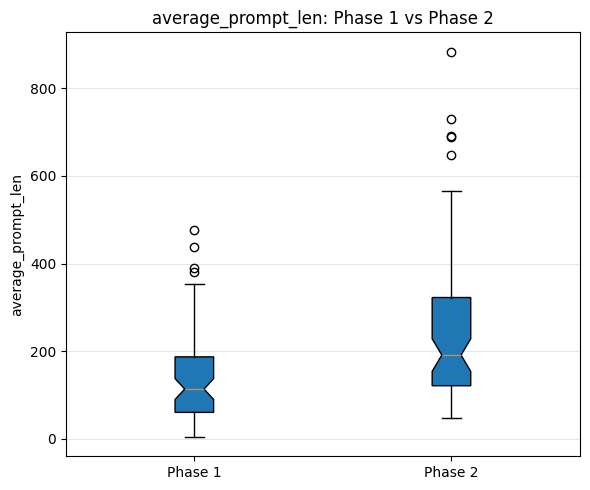

/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_56776/2948216586.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


Saved: prompt_types_results/average_prompt_len_notched_boxplot.png


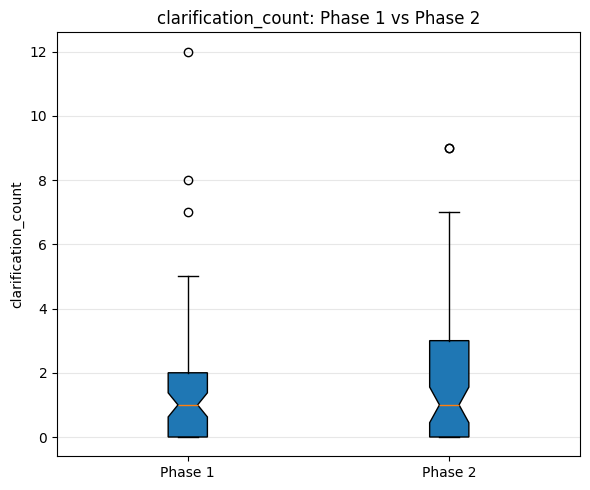

Saved: prompt_types_results/clarification_count_notched_boxplot.png


/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_56776/2948216586.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


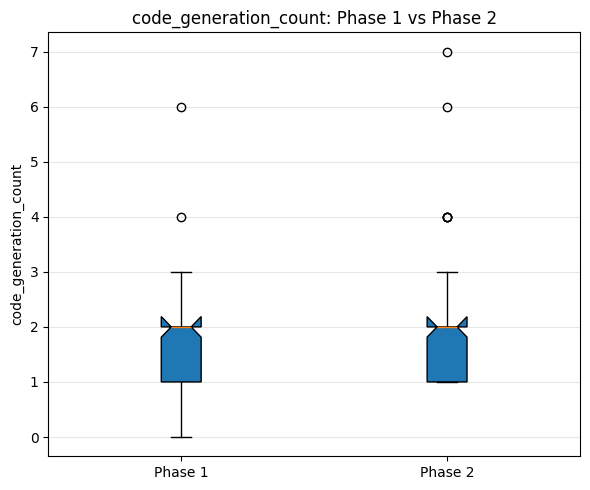

Saved: prompt_types_results/code_generation_count_notched_boxplot.png


/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_56776/2948216586.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


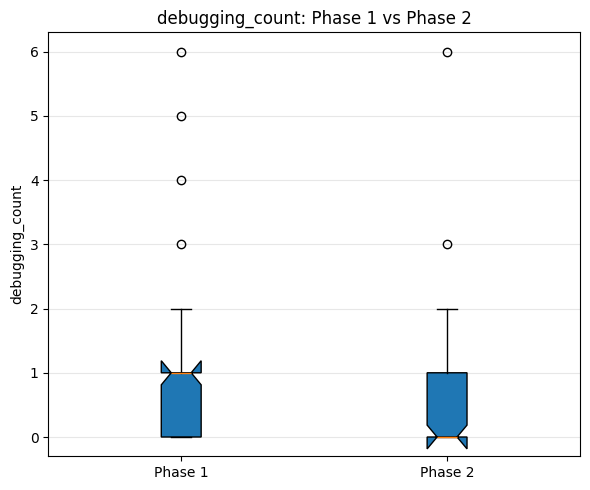

Saved: prompt_types_results/debugging_count_notched_boxplot.png


/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_56776/2948216586.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


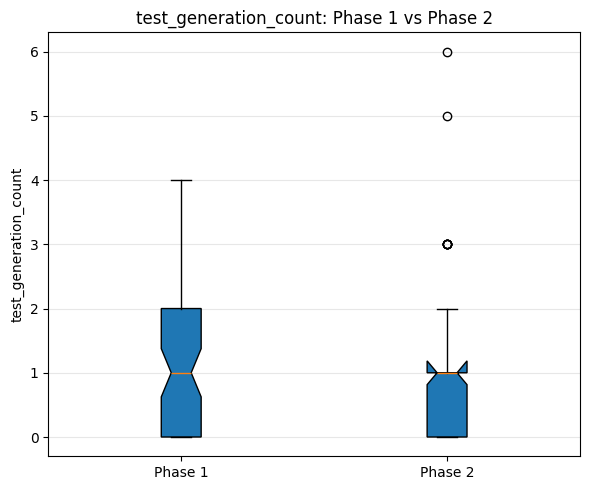

Saved: prompt_types_results/test_generation_count_notched_boxplot.png


/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_56776/2948216586.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


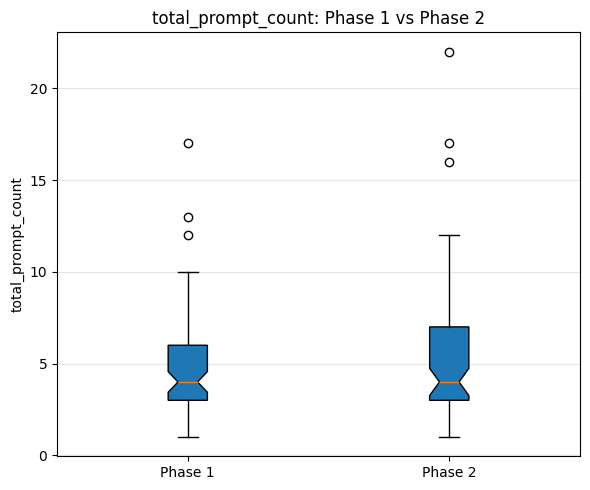

Saved: prompt_types_results/total_prompt_count_notched_boxplot.png


/var/folders/t8/pz3pwpn920vdzhd966m61fx80000gn/T/ipykernel_56776/2948216586.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


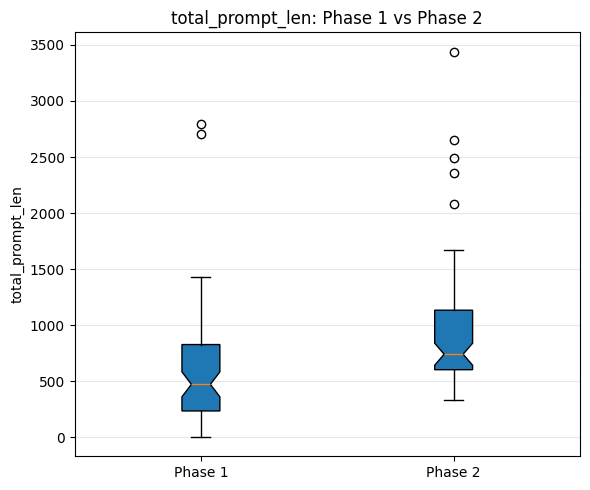

Saved: prompt_types_results/total_prompt_len_notched_boxplot.png


In [16]:
# -----------------------------
# Create one separate figure per column
# -----------------------------
for col in numeric_cols:
    data_phase1 = phase1[col].dropna()
    data_phase2 = phase2[col].dropna()

    plt.figure(figsize=(6, 5))

    plt.boxplot(
        [data_phase1, data_phase2],
        labels=["Phase 1", "Phase 2"],
        notch=True,
        patch_artist=True
    )

    plt.title(f"{col}: Phase 1 vs Phase 2")
    plt.ylabel(col)
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    output_path = os.path.join(output_dir, f"{col}_notched_boxplot.png")
    plt.savefig(output_path, dpi=300)
    plt.show()

    print(f"Saved: {output_path}")

Numeric columns to plot:
['total_prompt_count', 'total_prompt_len', 'average_prompt_len', 'clarification_count', 'debugging_count', 'code_generation_count', 'test_generation_count']


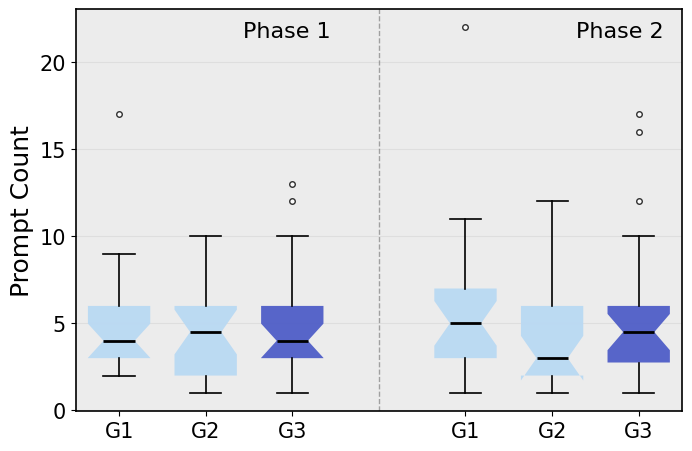

Saved: prompt_types_results/total_prompt_count_styled_notched_boxplot.pdf


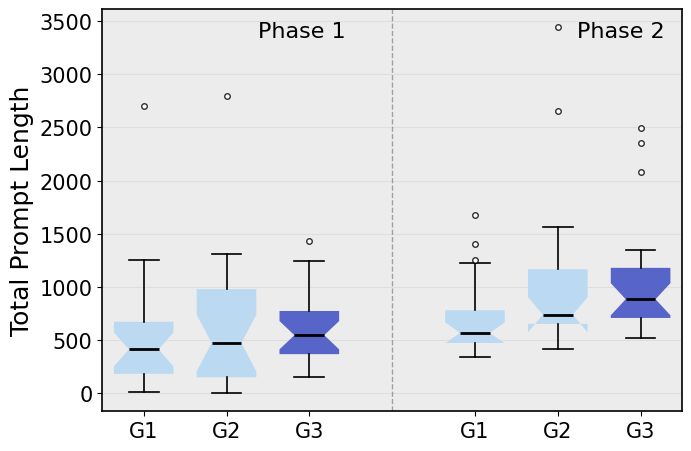

Saved: prompt_types_results/total_prompt_len_styled_notched_boxplot.pdf


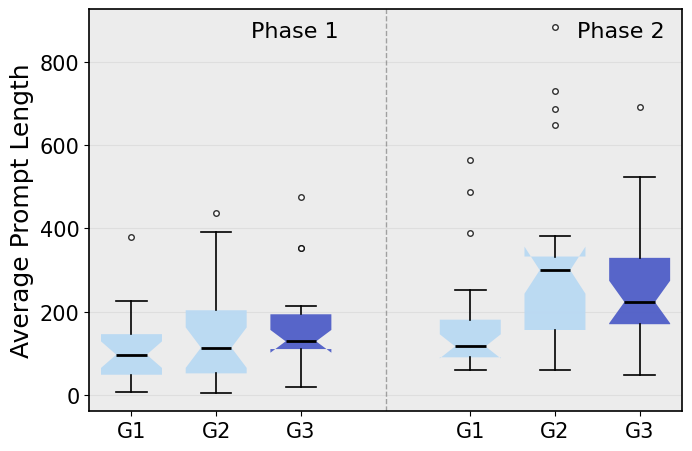

Saved: prompt_types_results/average_prompt_len_styled_notched_boxplot.pdf


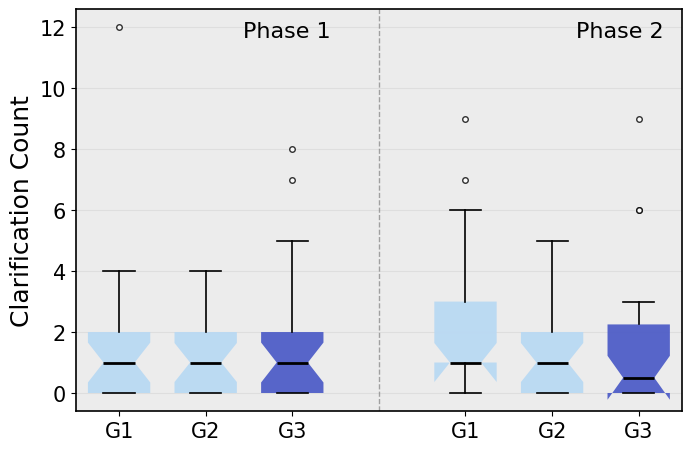

Saved: prompt_types_results/clarification_count_styled_notched_boxplot.pdf


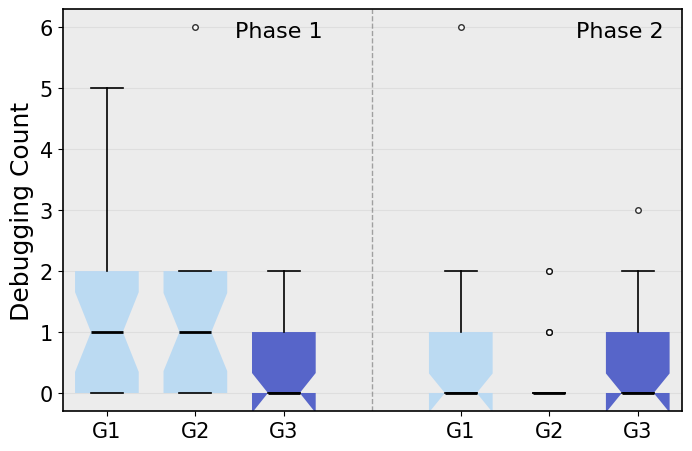

Saved: prompt_types_results/debugging_count_styled_notched_boxplot.pdf


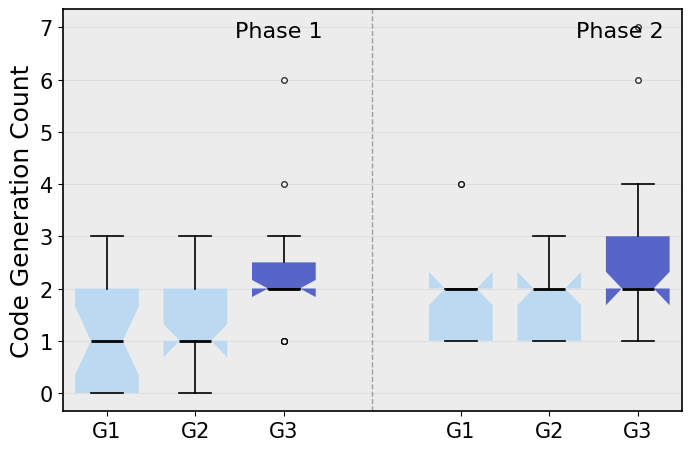

Saved: prompt_types_results/code_generation_count_styled_notched_boxplot.pdf


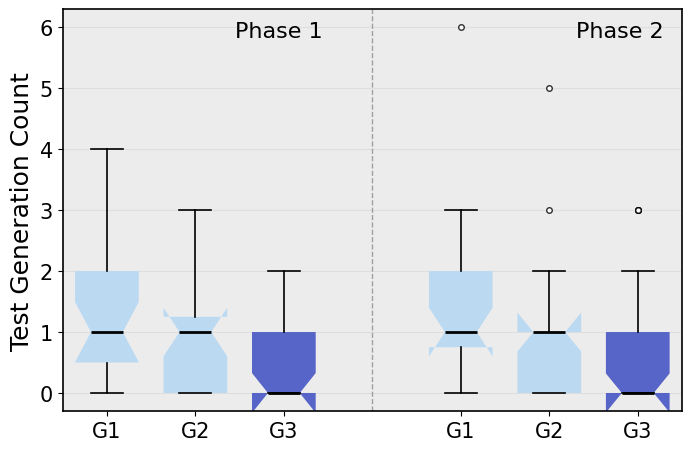

Saved: prompt_types_results/test_generation_count_styled_notched_boxplot.pdf


In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
phase1_summary_file = DATA_DIR / "prompt_data" / "Phase1_prompt_summary.csv"
phase2_summary_file = DATA_DIR / "prompt_data" / "Phase2_prompt_summary.csv"
phase1_dataset_file = DATA_DIR  / "dataset_phase1.csv"
phase2_dataset_file = DATA_DIR / "dataset_phase2.csv"


output_dir = "prompt_types_results"
os.makedirs(output_dir, exist_ok=True)

# -----------------------------
# Global style
# -----------------------------
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "axes.linewidth": 1.2
})

# -----------------------------
# Load files
# -----------------------------
phase1_summary = pd.read_csv(phase1_summary_file)
phase2_summary = pd.read_csv(phase2_summary_file)

phase1_dataset = pd.read_csv(phase1_dataset_file)
phase2_dataset = pd.read_csv(phase2_dataset_file)

# -----------------------------
# Standardize ID column
# -----------------------------
phase1_dataset = phase1_dataset.rename(columns={"anon_id": "id"})
phase2_dataset = phase2_dataset.rename(columns={"anon_id": "id"})

# -----------------------------
# Attach specification
# -----------------------------
if "specification" not in phase1_dataset.columns:
    raise ValueError("dataset_phase1.csv must contain a 'specification' column.")

phase1_meta = phase1_dataset[["id", "specification"]].drop_duplicates()

if "specification" in phase2_dataset.columns:
    phase2_meta = phase2_dataset[["id", "specification"]].drop_duplicates()
else:
    if "version" not in phase2_dataset.columns:
        raise ValueError(
            "dataset_phase2.csv needs either a 'specification' column or a 'version' column."
        )
    phase2_dataset["specification"] = phase2_dataset["version"].astype(str).str.extract(r"(G\d+)")
    phase2_meta = phase2_dataset[["id", "specification"]].drop_duplicates()

phase1 = phase1_summary.merge(phase1_meta, on="id", how="left")
phase2 = phase2_summary.merge(phase2_meta, on="id", how="left")

phase1["phase"] = "Phase 1"
phase2["phase"] = "Phase 2"

df = pd.concat([phase1, phase2], ignore_index=True)

# -----------------------------
# Numeric columns
# -----------------------------
numeric_cols = [
    col for col in df.select_dtypes(include="number").columns
]

print("Numeric columns to plot:")
print(numeric_cols)

# -----------------------------
# Pretty y-axis labels
# Edit these if you want different wording
# -----------------------------
ylabel_map = {
    "total_prompt_count": "Prompt Count",
    "total_prompt_len": "Total Prompt Length",
    "average_prompt_len": "Average Prompt Length",
    "clarification_count": "Clarification Count",
    "debugging_count": "Debugging Count",
    "code_generation_count": "Code Generation Count",
    "test_generation_count": "Test Generation Count",
}

# -----------------------------
# Group order
# -----------------------------
spec_order = ["G1", "G2", "G3"]
phase_order = ["Phase 1", "Phase 2"]

# positions with a gap between phases
positions = [1, 2, 3, 5, 6, 7]
labels = ["G1", "G2", "G3", "G1", "G2", "G3"]

# -----------------------------
# Colors to match the example
# G1, G2 = light blue
# G3 = darker blue
# -----------------------------
light_blue = "#b9d9f3"
dark_blue = "#4f5ec7"
box_colors = [light_blue, light_blue, dark_blue, light_blue, light_blue, dark_blue]

# -----------------------------
# Plot one figure per metric
# -----------------------------
for col in numeric_cols:
    data_to_plot = []

    for phase in phase_order:
        for spec in spec_order:
            vals = df[
                (df["phase"] == phase) &
                (df["specification"] == spec)
            ][col].dropna()
            data_to_plot.append(vals)

    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    ax.set_facecolor("#ececec")

    bp = ax.boxplot(
        data_to_plot,
        positions=positions,
        widths=0.72,
        notch=True,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2.0),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2),
        boxprops=dict(edgecolor="none", linewidth=0),
        flierprops=dict(
            marker='o',
            markersize=4,
            markerfacecolor="white",
            markeredgecolor="black",
            alpha=0.8
        )
    )

    # fill box colors
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.95)

    # x-axis labels = only specification groups
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)

    # proper y label
    ax.set_ylabel(ylabel_map.get(col, col.replace("_", " ").title()))

    # no title
    # ax.set_title(...)

    # subtle grid
    ax.grid(axis="y", alpha=0.22, linewidth=0.8)

    # separator between Phase 1 and Phase 2
    ax.axvline(4, color="gray", linestyle="--", linewidth=1.0, alpha=0.7)

    # phase labels INSIDE the plot near upper-right of each half
    ax.text(0.42, 0.97, "Phase 1",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=16)

    ax.text(0.97, 0.97, "Phase 2",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=16)

    plt.tight_layout()

    output_path = os.path.join(output_dir, f"{col}_styled_notched_boxplot.pdf")
    output_path_png= os.path.join(output_dir, f"{col}_styled_notched_boxplot.png")
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.savefig(output_path_png, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {output_path}")